Lugo Avalos Vanessa Aidee 6AM1

# Librerías
Se cargan las librerías necesarias para manipulación de datos, visualización con gráficas, división del conjunto de datos en entrenamiento y prueba, métricas, modelo a utilizar máquina de vectores de soporte, reducción de dimensionalidad con PCA, carga de datos y estandarización.

In [3]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Carga del conjunto de datos
Se carga e conjunto de datos usando su función load_digits(). Se trata de un conjunto de datos clásico para la calsifición de imágenes, pues tiene imagens de 8x8 píxeles de números escritos a mano en escala de grises. Así mismo, se asignan las variables independientes"X" con su función predeterminada, y la variable independiente con su función target.

In [4]:
digits = load_digits()
X, y = digits.data, digits.target

# Visualización del conjunto de datos (Una clase a la vez)
Se gráfica un único elemento de cada clase, de manera que la clase indica el digito que esta escrito de 0 a 9. 

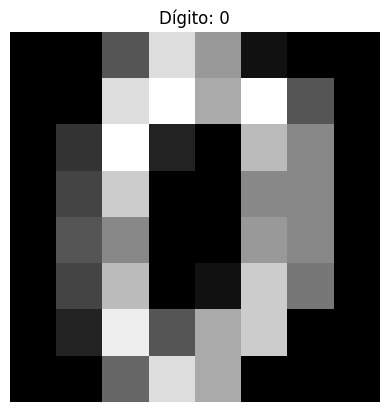

In [17]:
index = 0
plt.imshow(X[index].reshape(8, 8), cmap = 'gray') #Se visualiza la imagen
plt.title(f'Dígito: {y[index]}')
plt.axis('off')
plt.show()

# Visualización de un elemento de cada clase
Se realiza una gráfica con 10 paneles, en cada panel se muestra una imagen correspondiente a cada dígito.

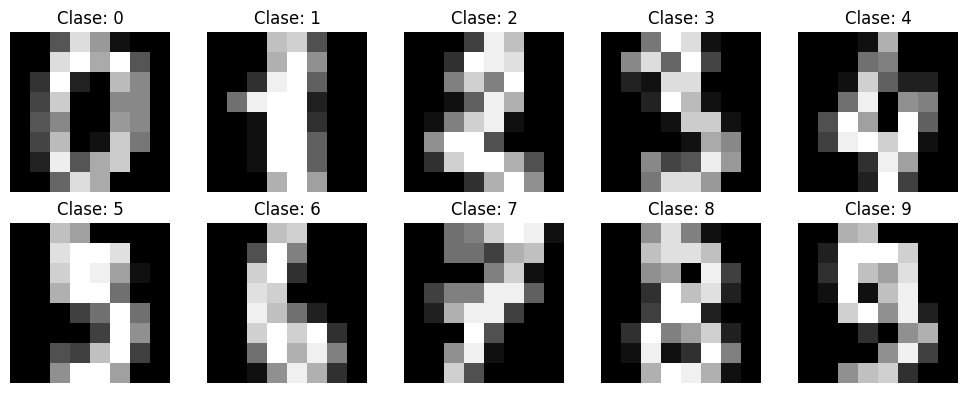

In [6]:
unique_digits = np.unique(y)#Se obtienen las clases únicas
indices = [np.where(y == digit)[0][0] for digit in unique_digits] #Se muestra la primer imagen de cada clase

plt.figure(figsize = (10, 4)) #Se establece la gráfica
for i, idx in enumerate(indices): #Se recorre usando un contador y el índice de los datos
    plt.subplot(2, 5, i + 1) #Se crea la gráfica de 2 filas x 5 colummas, y se va aumentando el contador para la gráfica
    plt.imshow(X[idx].reshape(8, 8), cmap = 'gray') #Se muestra la imagen
    plt.title(f"Clase: {y[idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Reducción a 2 dimensiones usando PCA y visualización de las clases
Se reduce la dimensionalidad original a 2, de manera que ahora se pueden visualizar los datos proyectados en dos dimensiones, es decir, en un plano cartesiano, para esto se aplica Análisis de Componentes Principales, la cual funciona estandarizando los datos, después se calula la maetriz de covarianza, y se obtinenen los vectores propios y valores propios.  
En este caso, se observa que los números que se pueden diferenciar de manera más simple son 0, 4 y 6, mientras que los números más complicados de diferenciar son el 5 y el 6. 

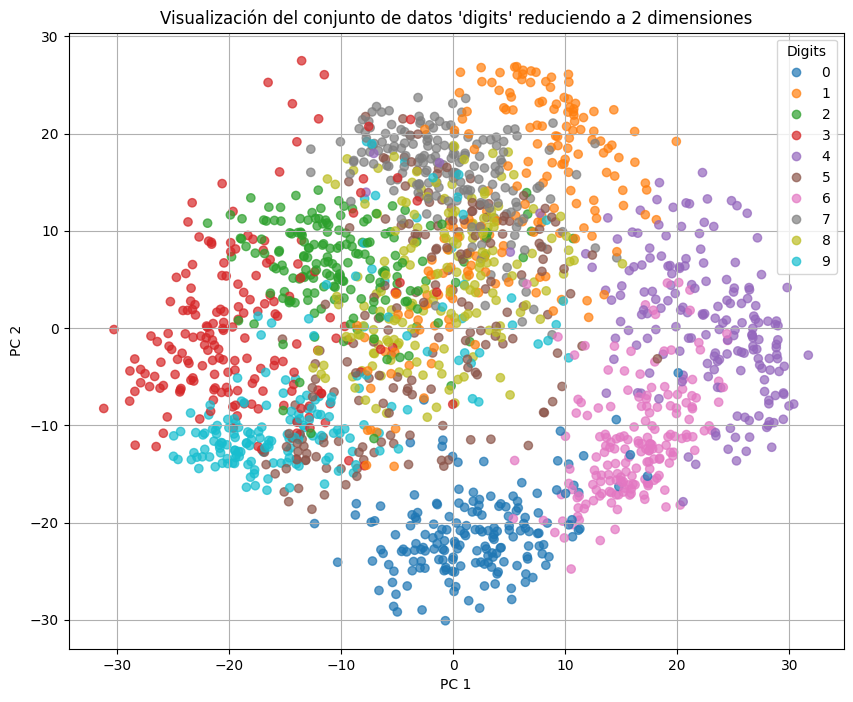

In [7]:
pca = PCA(n_components = 2) #Se usa la clase PCA y se definen las dimensiones
X_reduced = pca.fit_transform(X) #Se aplica PCA a los datos X

plt.figure(figsize=(10, 8)) #Se establece la gráfica
scatter = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c = y, cmap = 'tab10', alpha = 0.7)
plt.legend(*scatter.legend_elements(), title = "Digits")
plt.title("Visualización del conjunto de datos 'digits' reduciendo a 2 dimensiones")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.grid(True)
plt.show()

# División en conjunto de entrenamiento, prueba y escalado
Se realiza la división del conjunto de datos, teniendo el 30% de los datos para prueba y el 70% para entrenamiento, además se usa estratificación para el manejo del desbalance de clases. Después, se estandarizan usando la clase StandardScaler para cada conjunto de datos.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, stratify = y, random_state = 7)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Clasificación con Perceptrón Multicapa
El perceptrón multicapa es un tipo de red neuronal artificial compuesta por una capa de entrada, al menos una capa oculta, y una capa de salida. Esta red puede resolver problemas donde los datos no son linealmente separables. 

In [ ]:
#Se manda a llamar la clase para perceptrón multicapa y se asignan 100 capas
mlp_model = MLPClassifier(hidden_layer_sizes = (100,), max_iter = 300, random_state = 7)
mlp_model.fit(X_train_scaled, y_train) #Se entrena el modelo
mlp_preds = mlp_model.predict(X_test_scaled) #Se obtienen los valores predichos

# Reducción de dimensionalidad con PCA
Se realiza la reduccuión de dimensionalidad mediante análisis de componentes principales, dejando 30 dimensiones

In [11]:
pca = PCA(n_components = 30) #Se manda a llamar la clase para PCA
X_train_pca = pca.fit_transform(X_train_scaled) #Se aplica para entrenamiento
X_test_pca = pca.transform(X_test_scaled) #Se aplica para prueba

# Clasificación con Máquina de vectores de soporte con núcleo lineal
Se manda a llamar la clase de Máquina de vectores de soporte y se le establece un kernel de una función matemática lineal, así como una semilla aleatoria con valor 7. Después se entrena el modelo con los datos estandarizados y se obtienen las predicciones.    
El algoritmo de máquina de vectores de soporte es un algoritmo de aprendizaje supervisado para clasificación, de manera que trata de encontrar un hiperplano que separe el espacio de características de forma lineal con el máximo margen posible. 

In [9]:
svm_model = SVC(kernel = 'linear', random_state = 7) #Se establece clase para máquina de vectores de soporte
svm_model.fit(X_train_scaled, y_train) #Se entrena el modelo
svm_preds = svm_model.predict(X_test_scaled) #Se obtienen sus valores predichos

# Clasificación con Máquina de vectores de soporte con núcleo lineal y PCA
Se hace el entrenamiento del máquina de vectores de soporte usando los datos después de aplicar reducción de dimensionalidad a 30 con análisis de componentes múltiples.

In [12]:
svm_pca_model = SVC(kernel = 'linear', random_state = 7)
svm_pca_model.fit(X_train_pca, y_train)
svm_pca_preds = svm_pca_model.predict(X_test_pca)

# Clasificación con Perceptrón Multicapa y PCA
Se hace el entrenamiento del perceptrón multicapa usando los datos después de aplicar reducción de dimensionalidad a 30 con análisis de componentes múltiples.

In [13]:
mlp_pca_model = MLPClassifier(hidden_layer_sizes = (100,), max_iter = 300, random_state = 7)
mlp_pca_model.fit(X_train_pca, y_train)
mlp_pca_preds = mlp_pca_model.predict(X_test_pca)

# Resultados de todos los modelos
Se guaradan y muestran en un data frame todos los resultados obtenidos de aplicar máquina de vectores de soporte y perceptrón multicapa antes y después de reducir su dimensionalidad con ánalisis de componentes principales. Se obtiene los reportes de clasificaión de cada uno donde se tiene la sencibilidad, la puntuación f1 y el soporte. A continuación se muestran las formulas para calcular cada uno. 

Sensibilidad o exhaustividad (Recall): Mide qué porcentaje de los casos positivos fueron detectados correctamente.   
$$Recall = \frac{True Positive}{True Positive + False Negatives}$$
False Negative: Casos positivos en que el modelo clasificó como negativos.   
F1- Score: Métrica combinada que busca equilibrar la presición y el recall.  
$$F1 = 2(\frac{(Precision)(Recall)}{(Precision + Recall)})$$
Suport: Indica el número de instancias reales de cada clase en los datos de prueba

In [14]:
svm_report = classification_report(y_test, svm_preds, output_dict = True)
mlp_report = classification_report(y_test, mlp_preds, output_dict = True)
svm_pca_report = classification_report(y_test, svm_pca_preds, output_dict = True)
mlp_pca_report = classification_report(y_test, mlp_pca_preds, output_dict = True)

comparacion_df = pd.DataFrame({
    'SVM Precision': [svm_report[str(i)]['precision'] for i in range(10)],
    'MLP Precision': [mlp_report[str(i)]['precision'] for i in range(10)],
    'SVM + PCA Precision': [svm_pca_report[str(i)]['precision'] for i in range(10)],
    'MLP + PCA Precision': [mlp_pca_report[str(i)]['precision'] for i in range(10)],

    'SVM Recall': [svm_report[str(i)]['recall'] for i in range(10)],
    'MLP Recall': [mlp_report[str(i)]['recall'] for i in range(10)],
    'SVM + PCA Recall': [svm_pca_report[str(i)]['recall'] for i in range(10)],
    'MLP + PCA Recall': [mlp_pca_report[str(i)]['recall'] for i in range(10)],

    'SVM F1-Score': [svm_report[str(i)]['f1-score'] for i in range(10)],
    'MLP F1-Score': [mlp_report[str(i)]['f1-score'] for i in range(10)],
    'SVM + PCA F1-Score': [svm_pca_report[str(i)]['f1-score'] for i in range(10)],
    'MLP + PCA F1-Score': [mlp_pca_report[str(i)]['f1-score'] for i in range(10)],
}, index=[f'Digit {i}' for i in range(10)])

comparacion_df

,SVM Precision,MLP Precision,SVM + PCA Precision,MLP + PCA Precision,SVM Recall,MLP Recall,SVM + PCA Recall,MLP + PCA Recall,SVM F1-Score,MLP F1-Score,SVM + PCA F1-Score,MLP + PCA F1-Score
Digit 0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Digit 1,0.946429,0.982143,0.946429,0.963636,0.963636,1.000000,0.963636,0.963636,0.954955,0.990991,0.954955,0.963636
Digit 2,1.000000,1.000000,0.980769,1.000000,1.000000,1.000000,0.962264,1.000000,1.000000,1.000000,0.971429,1.000000
Digit 3,0.964912,0.981818,0.945455,0.981818,1.000000,0.981818,0.945455,0.981818,0.982143,0.981818,0.945455,0.981818
Digit 4,1.000000,0.981481,0.964286,1.000000,1.000000,0.981481,1.000000,0.962963,1.000000,0.981481,0.981818,0.981132
Digit 5,0.963636,0.981132,0.947368,0.963636,0.963636,0.945455,0.981818,0.963636,0.963636,0.962963,0.964286,0.963636
Digit 6,0.981481,0.963636,0.981481,0.963636,0.981481,0.981481,0.981481,0.981481,0.981481,0.972477,0.981481,0.972477
Digit 7,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.981481,1.000000,1.000000,1.000000,0.990654,1.000000
Digit 8,0.890909,0.961538,0.875000,0.962963,0.942308,0.961538,0.942308,1.000000,0.915888,0.961538,0.907407,0.981132
Digit 9,0.958333,0.962963,0.978723,0.962264,0.851852,0.962963,0.851852,0.944444,0.901961,0.962963,0.910891,0.953271


# Matriz de confusión de los resultados
Se calculan y visualizan las matrices de confusión de cada algoritmo, de manera que se genera una gráfica que engloble estos cuatro. Los cuatro modelos tuvieron un rendimiento bastasnte similar, solo máquinas de vectores de soporte supera con PCA supera por muy poco a su versión sin PCA, mientras que el perceptrón multicapa con PCA y sin este se mantiene practicamnet igual. 

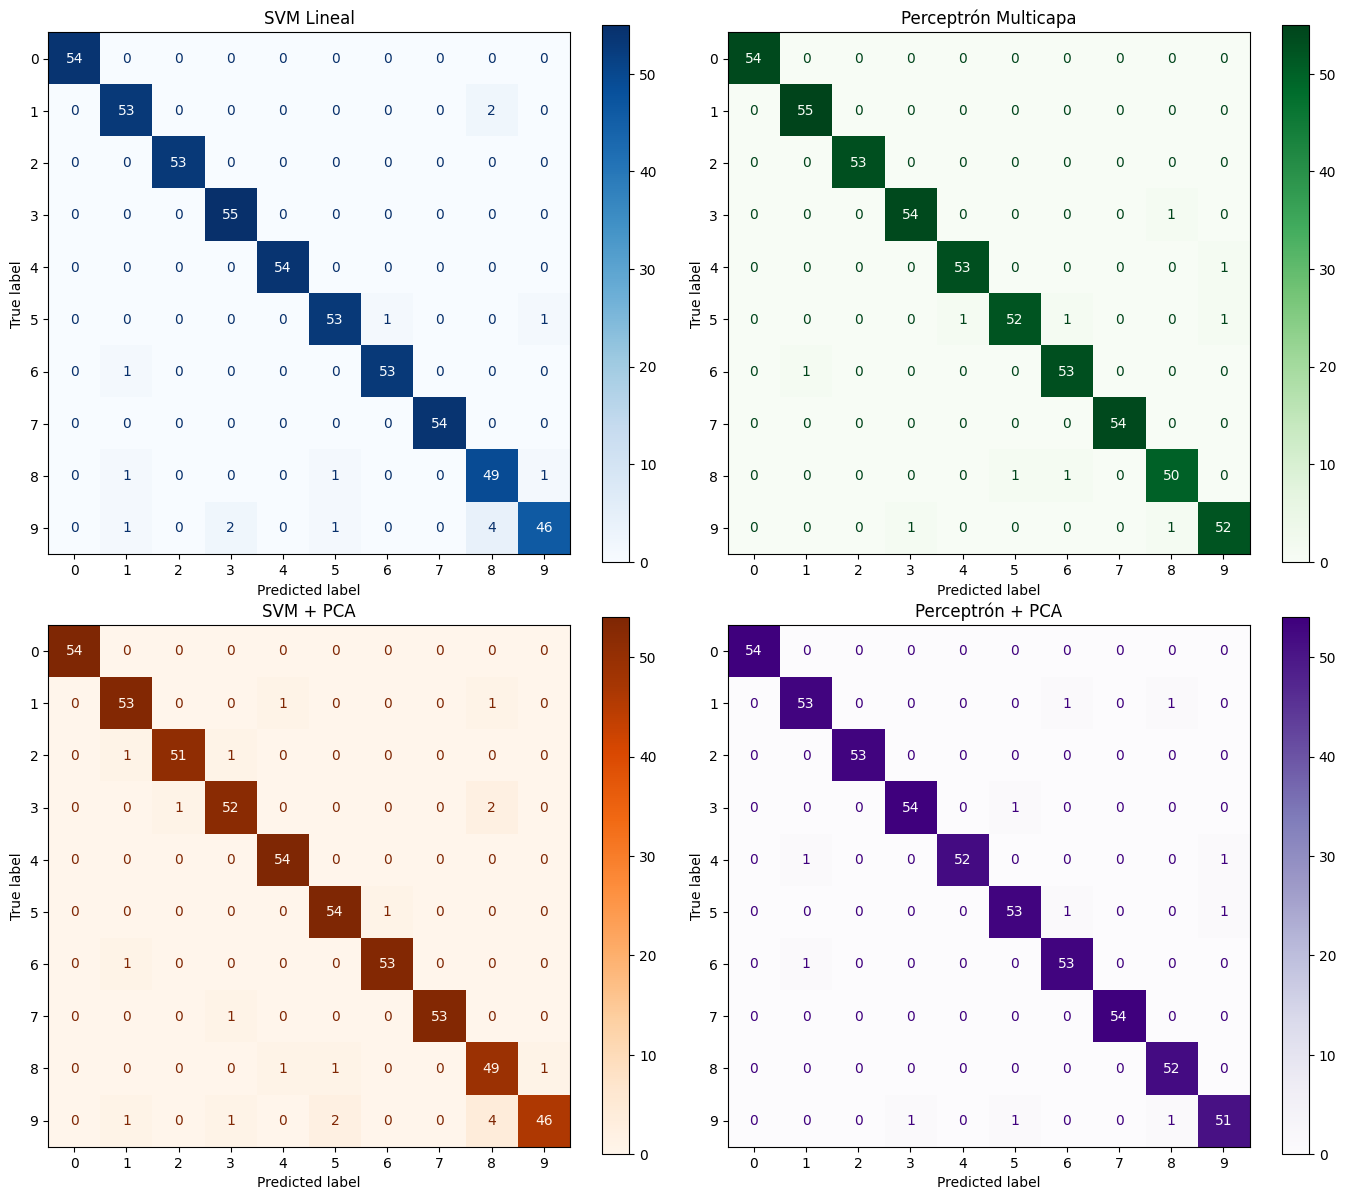

In [15]:
fig, axs = plt.subplots(2, 2, figsize = (14, 12))

ConfusionMatrixDisplay.from_estimator(svm_model, X_test_scaled, y_test, ax = axs[0, 0], cmap = 'Blues')
axs[0, 0].set_title("SVM Lineal")

ConfusionMatrixDisplay.from_estimator(mlp_model, X_test_scaled, y_test, ax = axs[0, 1], cmap = 'Greens')
axs[0, 1].set_title("Perceptrón Multicapa")

ConfusionMatrixDisplay.from_estimator(svm_pca_model, X_test_pca, y_test, ax = axs[1, 0], cmap = 'Oranges')
axs[1, 0].set_title("SVM + PCA")

ConfusionMatrixDisplay.from_estimator(mlp_pca_model, X_test_pca, y_test, ax = axs[1, 1], cmap = 'Purples')
axs[1, 1].set_title("Perceptrón + PCA")

plt.tight_layout()
plt.show()

# Clasificación con SVM y PCA con solo 2 dimensiones (Dígitos 0 y 1)
Se hace la prueba de estos algortmos pero usando esta vez solo dos salidas, 0 o 1, de manera que se convierte en una clasificaicón binaria.

In [16]:
mask = (y == 0) | (y == 1) #Asignar clases 0 o 1
X_binary = X[mask] #Datos de X solo con los datos binarios
y_binary = y[mask] #Datos de y solo con los datos binarios

# Reducción de dimensiones con PCA
Se realiza una reduccón de los datos a unicamente 2 dimensiones mediante PCA, similar a la primer gráfica donde se observa esta reducción

In [15]:
pca_2d = PCA(n_components=2) #Se establecen dos dimensiones
X_binary_pca = pca_2d.fit_transform(X_binary) #Se aplica con los datos binarios

# Modelo SVM y PCA
Se aplica el modelo de máquina de vectores de soporte y se entrena con los datos que tuvieron una reducción de dimensionanlidad a 2. 

In [16]:
svm_binary_2d = SVC(kernel = 'linear', random_state = 7)
svm_binary_2d.fit(X_binary_pca, y_binary)

support_vectors = svm_binary_2d.support_vectors_

# Frontera de decisión
Se establece la frontera de decisión, que se trata del hiperplano que trata de separar estos datos. En este caso, se trata de una linea recta, pues esta es capaz de separar datos que se encuentran en dos dimensiones. Primero se encuentran los valores mínimos y máximos de los datos, después se crean 500 puntos espaciados de manera equitativa y se guardan las coordenadas. Finalmente se hace el cálculo de la función de decisión convirtiendo lass matrices en vectores de una dimensión y se calcula la distancia con signo a la frontera de decisión. 

In [17]:
x_min, x_max = X_binary_pca[:, 0].min() - 1, X_binary_pca[:, 0].max() + 1 #Limite de la gráfica
y_min, y_max = X_binary_pca[:, 1].min() - 1, X_binary_pca[:, 1].max() + 1 #Limite de la gráfica
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), #Se crea la matriz de coordenadas
                     np.linspace(y_min, y_max, 500))

Z = svm_binary_2d.decision_function(np.c_[xx.ravel(), yy.ravel()]) #Se calculan las disntancias
Z = Z.reshape(xx.shape) #Se vuelve a organizar la matriz

# Visualización de la frontera
Se crea una gráfica para visualizar la manera en que funciona máquina de vectores de soporte, esta linea separa a las clases de los datos, que en este caso es el digito 0 y el digito 1, y se puede observar que se esta clasificando de manera correcta.

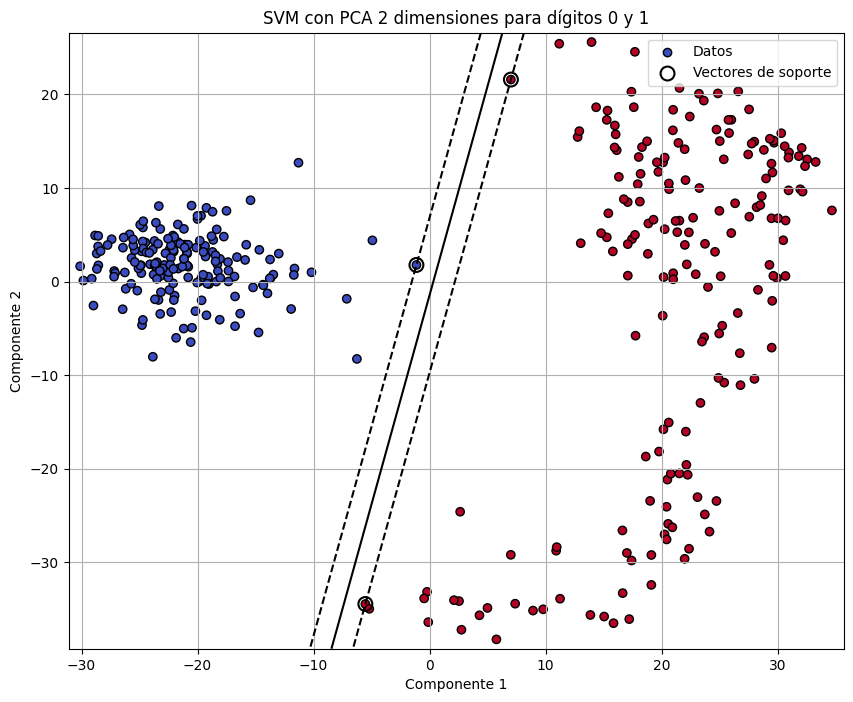

In [18]:
plt.figure(figsize = (10, 8))
plt.contour(xx, yy, Z, levels = [-1, 0, 1], linestyles = ['--', '-', '--'], colors = 'k')
plt.scatter(X_binary_pca[:, 0], X_binary_pca[:, 1], c = y_binary, cmap = 'coolwarm', edgecolors = 'k', label = 'Datos')
plt.scatter(support_vectors[:, 0], support_vectors[:, 1], s = 100, facecolors = 'none', edgecolors = 'black',
            linewidths = 1.5, label = 'Vectores de soporte')

plt.title("SVM con PCA 2 dimensiones para dígitos 0 y 1")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.legend()
plt.grid(True)
plt.show()

# Conclusión
Para concluir, ambos algoritmos tienen un rendimiento bastante similar de acuerdo a lo visto en sus matrices de confusión y el reporte de clasificación, así mismo, se tiene un rendimiento muy similar si se mantienen todas las dimensiones o si se realiza la reducción a 30. Así mismo, se logro visualizar una gráfica simple para observar como funciona la frontera de decisión en la máquina de vectores de soporte.